# Imports

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import pickle
from collections import defaultdict
from tqdm.notebook import trange, tqdm
from icecream import ic

import pandas as pd
import numpy as np
import scipy
import sklearn
import prince

import seaborn as sns
from matplotlib import pyplot as plt

from plotly import express as px
from plotly import graph_objects as go
import plotly.io as pio

In [4]:
from rsfp.metrics import *
from rsfp.constants import *
from rsfp.data import *
from rsfp.matching import *
from rsfp.dimensionality_reduction import *
from rsfp.utils import *

In [5]:
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 200)
pd.options.plotting.backend = "plotly"

# Data

## 2023

In [11]:
# load 2023 datasets
df_voters, df_candidates, df_questions = build_all(verbose=True)

Preprocessed voter DataFrame found.
Cleaned voter DataFrame found.
Cleaned candidate DataFrame found.


In [ ]:
# load uncleaned 2023 voter dataset
df_voters_all = build_voters(clean=False)
df_voters_all

In [6]:
# load recommendation data for L2 distance metric
df_voters = df_voters.load_candidate_voting_recommendations('df_voters_recommendations_spc_10_methods', selected_distance_methods=['L2_sv'])
df_candidates = df_candidates.load_candidate_recommendation_counts('df_candidates_recommendations_spc_10_methods', selected_distance_methods=['L2_sv'])

In [ ]:
# load list recommendations for L2 distance metric
df_voters = df_voters.load_list_voting_recommendations('df_voters_list_recommendations_10_methods', selected_distance_methods=['L2_sv'])

In [276]:
# load recommendation data for evaluated distance metrics
df_voters = df_voters.load_candidate_voting_recommendations('df_voters_recommendations_spc_10_methods', selected_distance_methods=EVAL_DISTANCE_METHODS)
df_candidates = df_candidates.load_candidate_recommendation_counts('df_candidates_recommendations_spc_10_methods', selected_distance_methods=EVAL_DISTANCE_METHODS)

In [ ]:
# load list recommendations for evaluated distance metrics
df_voters = df_voters.load_list_voting_recommendations('df_voters_list_recommendations_10_methods', selected_distance_methods=EVAL_DISTANCE_METHODS)

In [14]:
# add dimensionality reduction columns
df_candidates, obj = add_pca_cols(df_candidates, n_dims=2, return_obj=True)
df_voters = add_pca_cols(df_voters, n_dims=2, obj=obj)

df_candidates, obj = add_ca_cols(df_candidates, n_dims=2, return_obj=True)
df_voters = add_ca_cols(df_voters, n_dims=2, obj=obj)

df_candidates, obj = add_tsvd_cols(df_candidates, n_dims=2, return_obj=True)
df_voters = add_tsvd_cols(df_voters, n_dims=2, obj=obj)

In [ ]:
# plot PCA distribution of candidates
fig = px.scatter(df_candidates[~df_candidates['_party'].isin(['Parteilos', 'Andere'])], x='PCA_0', y='-PCA_1', color='_party', color_discrete_map=PARTY2COLOR)
fig.update_layout(
    xaxis_title='Left - Right',
    yaxis_title='Conservative - Liberal',
    legend=dict(
        title='Party',
        x=1,
        y=1,
        xanchor='left',
        yanchor='top',
        itemsizing='constant',
    )
).update_traces(marker_size=3)


## 2019

In [62]:
# load 2019 datasets
df_voters19, df_candidates19, df_questions19 = build_all19(verbose=True)

No cleaned voter19 DataFrame found. Cleaning starts now.
No cleaned candidate19 DataFrame found. Cleaning starts now.


In [ ]:
# load uncleaned 2019 voter dataset
df_voters19_all = build_voters19(clean=False)

In [6]:
# load recommendation data for L2 distance metric
df_voters19 = df_voters19.load_candidate_voting_recommendations('df_voters19_recommendations_spc_10_methods', selected_distance_methods=['L2_sv'])
df_candidates19 = df_candidates19.load_candidate_recommendation_counts('df_candidates19_recommendations_spc_10_methods', selected_distance_methods=['L2_sv'])

In [ ]:
# load list recommendations for L2 distance metric
df_voters19 = df_voters19.load_list_voting_recommendations('df_voters19_list_recommendations_10_methods', selected_distance_methods=['L2_sv'])

In [276]:
# load recommendation data for evaluated distance metrics
df_voters19 = df_voters19.load_candidate_voting_recommendations('df_voters19_recommendations_spc_10_methods', selected_distance_methods=EVAL_DISTANCE_METHODS)
df_candidates19 = df_candidates19.load_candidate_recommendation_counts('df_candidates19_recommendations_spc_10_methods', selected_distance_methods=EVAL_DISTANCE_METHODS)

In [ ]:
# load list recommendations for evaluated distance metrics
df_voters19 = df_voters19.load_list_voting_recommendations('df_voters19_list_recommendations_10_methods', selected_distance_methods=EVAL_DISTANCE_METHODS)

In [ ]:
# add dimensionality reduction columns
df_candidates19, obj = add_pca_cols(df_candidates19, n_dims=2, return_obj=True)
df_voters19 = add_pca_cols(df_voters19, n_dims=2, obj=obj)

df_candidates19, obj = add_ca_cols(df_candidates19, n_dims=2, return_obj=True)
df_voters19 = add_ca_cols(df_voters19, n_dims=2, obj=obj)

df_candidates19, obj = add_tsvd_cols(df_candidates19, n_dims=2, return_obj=True)
df_voters19 = add_tsvd_cols(df_voters19, n_dims=2, obj=obj)

In [37]:
# uncleaned df_voters19 with helpful columns (same dataset as Leon)

# build df_voters19 without cleaning
df_voters19 = build_voters19(clean=False)

# map weights from categorical to numeric values
weight_map = {
    1: 0.5,
    2: 1,
    3: 2,
}
weight_cols = get_cols(df_voters19, col_type='weight')
answer_cols = get_cols(df_voters19, col_type='answer')

df_voters19[weight_cols] = df_voters19[weight_cols].map(weight_map.get)

# add decoded columns
decoded_columns = {
    '_party': df_voters19['party'].map(ID2PARTY19),
    '_education': df_voters19['education'].map(ID2EDUCATION),
    '_district': df_voters19['ID_district'].map(ID2DISTRICT19),
    '_gender': df_voters19['gender'].map(ID2GENDER19),
    '_language': df_voters19['language'].map(ID2LANGUAGE19)
}
df_decoded = pd.concat(decoded_columns, axis=1)

# merge decoded columns with original DataFrame
df_voters19 = pd.concat([df_voters19, df_decoded], axis=1)

# add stats columns
df_voters19['_answer_strength'] = (df_voters19[answer_cols] - 50).abs().mean(axis=1)
df_voters19['_answer_strength_std'] = (df_voters19[answer_cols] - 50).abs().std(axis=1)

df_voters19['_maxDist_L2_sv'] = np.sqrt(((df_voters19[weight_cols] * 100) ** 2).sum(axis=1))

max_diff = df_voters19[answer_cols].map(lambda x: max(x, 100 - x)).to_numpy()
weights = df_voters19[weight_cols].to_numpy()
df_voters19['_maxDistCorrect_L2_sv'] = np.sqrt(np.nansum((max_diff * weights) ** 2, axis=1))

# calculate recommendations
df_voters19 = add_candidate_voting_recommendations(df_voters19, df_candidates19)
df_candidates19 = df_candidates19.add_recommendation_counts(df_voters19)

# Answer Optimization (AO)

In [64]:
# Helper Functions

def map_to_answer_possibilities_candidate(answer_vector):
    # Ensure the input vector does not contain NaN values
    if np.isnan(answer_vector).any():
        raise ValueError("Answer vector contains NaN values. Please ensure the input is valid.")

    # Define the possible discrete values for each segment
    possible_values_1 = np.array([0, 25, 75, 100])
    possible_values_2 = np.array([0, 17, 33, 50, 67, 83, 100])
    possible_values_3 = np.array([0, 25, 50, 75, 100])

    # Vectorized operation to map the first 60 elements
    diffs_1 = np.abs(answer_vector[:60, np.newaxis] - possible_values_1)
    answer_vector[:60] = possible_values_1[np.argmin(diffs_1, axis=1)]
    
    # Vectorized operation to map elements 60 to 66
    diffs_2 = np.abs(answer_vector[60:67, np.newaxis] - possible_values_2)
    answer_vector[60:67] = possible_values_2[np.argmin(diffs_2, axis=1)]
    
    # Vectorized operation to map elements 67 to 74
    diffs_3 = np.abs(answer_vector[67:75, np.newaxis] - possible_values_3)
    answer_vector[67:75] = possible_values_3[np.argmin(diffs_3, axis=1)]

    return answer_vector



def add_crafted_candidate(df, candidate_answer_vector, candidate_id: int = 1, term: int = 2023):
    df = df.copy()
    df = SVDataFrame(pd.concat([pd.DataFrame([df.iloc[0]]), df], ignore_index=True), term=term)
    df.loc[0, 'ID_candidate'] = candidate_id # candidate id of 1 (no other candidate)
    df.loc[0, 'lastname'] = 'AAAAAAAAAAA'  # optimal last name
    df.loc[0, get_cols(df)] = map_to_answer_possibilities_candidate(candidate_answer_vector)
    return df



def load_x0_if_available(district, df_c_district, use_first_percent: bool = False, use_2019: bool = False):
    """
    This function checks if an .npy file with the optimized answer vector for the specified district exists.
    If the file exists, it loads and returns the vector. Otherwise, it returns None.

    Args:
    - district (str): The district name or identifier.

    Returns:
    - np.ndarray: The loaded answer vector if the file exists, otherwise None.
    """
    filename = f'answer_optimization/answer_optimization_vector_{"2019_" if use_2019 else ""}{district}{"_firstperc" if use_first_percent else ""}.npy'

    # Check if the file exists
    if os.path.isfile(filename):
        # Load and return the vector
        return np.load(filename)
    else:
        # Return None if the file does not exist
        return df_c_district[df_c_district['_n_recommendations_spc_L2_sv'] == df_c_district[
            '_n_recommendations_spc_L2_sv'].max()].a().to_numpy().ravel()

## Dual Annealing

In [9]:
import time
import numpy as np
from scipy.optimize import dual_annealing
import pandas as pd
from IPython.display import clear_output, display


# Optimization Hyperparameters
initial_temp = 10
restart_temp_ratio = 1e-4
visit=None
accept=None
seed = 0
time_limit = 600  # 1 hour

# Load Data
district = 'SG'

use_2019 = False
use_first_percent = False

if use_2019:
    df_v_district = df_voters19.district(district).sort_values('_time').head(int(0.01*len(df_voters19.district(district)))) if use_first_percent else df_voters19.district(district)
    df_c_district = df_candidates19.district(district)
    threshold_dists = df_v_district[f'_matchDist_{SEATS_PER_CANTON19[district]}_L2_sv'].to_numpy()

else:
    df_v_district = df_voters.district(district).sort_values('_time').head(int(0.01*len(df_voters.district(district)))) if use_first_percent else df_voters.district(district)
    df_c_district = df_candidates.district(district)
    threshold_dists = df_v_district[f'_matchDist_{SEATS_PER_CANTON[district]}_L2_sv'].to_numpy()

voter_answers = df_v_district.a().to_numpy()
voter_weights = df_v_district.w().to_numpy()


# Initialize variable to keep track of the best visibility
best_visibility = float('-inf')
count = 0

# Define the objective function that takes the candidate answer vector as input and returns the visibility
def objective_function(candidate_answer_vector, voter_answers, voter_weights, threshold_dists):
    global best_visibility
    global count

    candidate_answer_vector_discretized = map_to_answer_possibilities_candidate(candidate_answer_vector)

    crafted_candidate_dists = calculate_distances(voter_answers, candidate_answer_vector_discretized.reshape(1, -1), voter_weights)

    visibility = (crafted_candidate_dists.ravel() <= threshold_dists).mean()

    # Check if this is a new high score
    if visibility > best_visibility:
        best_visibility = visibility
        print(f"New high score: Visibility = {visibility}")
        
        # Save the candidate answer vector to a .npy file
        np.save(f'answer_optimization/answer_optimization_vector_{"2019_" if use_2019 else ""}{district}{"_firstperc" if use_first_percent else ""}.npy', candidate_answer_vector_discretized)

    count += 1
    # Clear the previous output
    if count % 100 == 0:
        clear_output(wait=True)
        display(f"Current Visibility: {visibility} - Best Visibility: {best_visibility} - Function Evaluations: {count}")
    
    return -visibility  # Return the negative visibility since we are minimizing by default

# Define bounds for each element of the candidate answer vector (values between 0 and 100)
bounds = [(0, 100) for _ in range(75)]

# Record the start time
start_time = time.time()

def time_limited_objective(candidate_answer_vector):
    # Check if the time limit has been exceeded
    if time.time() - start_time > time_limit:
        raise TimeoutError("Time limit exceeded")
    
    # Call the original objective function
    return objective_function(candidate_answer_vector, voter_answers, voter_weights, threshold_dists)

try:
    # Simulated Annealing optimization
    result = dual_annealing(
        time_limited_objective, 
        bounds, 
        maxiter=100000,  # Set a large maxiter, the time limit will be the actual stopper
        initial_temp=initial_temp, 
        restart_temp_ratio=restart_temp_ratio, 
        #visit=visit,
        #accept=accept,
        x0=load_x0_if_available(district, df_c_district, use_first_percent, use_2019),  # Provide the initial guess,
        #no_local_search=True,
        seed=seed
    )
except TimeoutError:
    # Handle the timeout and retrieve the best solution found so far
    print(f"Time limit of {time_limit} seconds exceeded!")
else:
    # Normal completion
    optimized_vector = result.x
    optimized_visibility = -result.fun

    # Print the results
    print("Optimized Candidate Answer Vector:", optimized_vector)
    print("Optimized Visibility:", optimized_visibility)


'Current Visibility: 0.06028226541701615 - Best Visibility: 0.6171182670216258 - Function Evaluations: 500'

KeyboardInterrupt: 

## Powell's Method

In [92]:
import time
import numpy as np
from scipy.optimize import minimize
import pandas as pd
import os
from IPython.display import clear_output, display

# Optimization Hyperparameters
seed = 0
time_limit = 30  # 30 seconds

# Load Data
district = 'BE'
df_v_district = df_voters.district(district)
df_c_district = df_candidates.district(district)

# Duplicate the first row (crafted candidate)
df_c_district_crafted_candidate = SVDataFrame(pd.concat([pd.DataFrame([df_c_district.iloc[0]]), df_c_district], ignore_index=True), term=2023)
df_c_district_crafted_candidate.loc[0, 'ID_candidate'] = 1   # unique candidate id to identify
df_c_district_crafted_candidate.loc[0, 'lastname'] = 'AAAAAA'  # optimal lastname for tie-breaking

# Initialize variable to keep track of the best visibility
best_visibility = float('-inf')
count = 0

def load_x0_if_available(district):
    """
    This function checks if an .npy file with the optimized answer vector for the specified district exists.
    If the file exists, it loads and returns the vector. Otherwise, it returns None.
    
    Args:
    - district (str): The district name or identifier.

    Returns:
    - np.ndarray: The loaded answer vector if the file exists, otherwise None.
    """
    filename = f'answer_optimization/answer_optimization_vector_{district}.npy'
    
    # Check if the file exists
    if os.path.isfile(filename):
        # Load and return the vector
        return np.load(filename)
    else:
        # Return None if the file does not exist
        return None
    

# Define the objective function that takes the candidate answer vector as input and returns the visibility
def objective_function(candidate_answer_vector, df_v_district, df_c_district_crafted_candidate):
    global best_visibility
    global count

    # Insert candidate in first row
    df_c_district_crafted_candidate.loc[0, get_cols(df_c_district_crafted_candidate)] = map_to_answer_possibilities_candidate(candidate_answer_vector)

    # Compute candidate recommendations
    df_v_district_updated = add_candidate_voting_recommendations(df_v_district, df_c_district_crafted_candidate, progress_bar=False)
    
    # Count how often candidate ID 1 appears in recommendations
    visibility = (df_v_district_updated[[c for c in df_v_district_updated.columns if c.startswith('_matchID') and c.endswith('L2_sv')]] == 1).sum().sum() / len(df_v_district_updated)

    # Check if this is a new high score
    if visibility > best_visibility:
        best_visibility = visibility
        print(f"New high score: Visibility = {visibility}")
        
        # Save the candidate answer vector to a .npy file
        np.save(f'answer_optimization/answer_optimization_vector_{district}.npy', candidate_answer_vector)

    count += 1
    # Clear the previous output
    clear_output(wait=True)
    display(f"Best Visibility: {best_visibility} - Function Evaluations: {count}")
    
    return -visibility  # Return the negative visibility since we are minimizing by default

# Define the initial guess (x0)
x0 = load_x0_if_available(district)
if x0 is None:
    x0 = np.random.uniform(low=0, high=100, size=75)  # If no initial guess is available, generate a random one

# Define bounds for each element of the candidate answer vector (values between 0 and 100)
bounds = [(0, 100) for _ in range(75)]

# Record the start time
start_time = time.time()

def time_limited_objective(candidate_answer_vector):
    # Check if the time limit has been exceeded
    if time.time() - start_time > time_limit:
        raise TimeoutError("Time limit exceeded")
    
    # Call the original objective function
    return objective_function(candidate_answer_vector, df_v_district, df_c_district_crafted_candidate)

try:
    # Powell's optimization method
    result = minimize(
        time_limited_objective,
        x0,
        method='Powell',
        bounds=bounds,
        options={'maxiter': 100000, 'disp': True}
    )
except TimeoutError:
    # Handle the timeout and retrieve the best solution found so far
    print(f"Time limit of {time_limit} seconds exceeded!")
else:
    # Normal completion
    optimized_vector = result.x
    optimized_visibility = -result.fun

    # Print the results
    print("Optimized Candidate Answer Vector:", optimized_vector)
    print("Optimized Visibility:", optimized_visibility)

'Best Visibility: 0.10105395063662198 - Function Evaluations: 1'

KeyboardInterrupt: 

In [ ]:
import numpy as np
from scipy.optimize import minimize
import pandas as pd

district = 'GE'
df_v_district = df_voters.district(district)
df_c_district = df_candidates.district(district)

# Duplicate the first row
first_row = df_c_district.iloc[0]  # Select the first row
df_c_district_crafted_candidate = SVDataFrame(pd.concat([pd.DataFrame([first_row]), df_c_district], ignore_index=True), term=2023)
df_c_district_crafted_candidate.loc[0, 'ID_candidate'] = 1

# Define the objective function that takes the candidate answer vector as input and returns the visibility
def objective_function(candidate_answer_vector, df_v_district, df_c_district_crafted_candidate):

    # Insert candidate in the first row
    df_c_district_crafted_candidate.loc[0, get_cols(df_c_district_crafted_candidate)] = candidate_answer_vector

    # Compute candidate recommendations
    df_v_district_updated = add_candidate_voting_recommendations(df_v_district, df_c_district_crafted_candidate)
    
    # Count how often candidate ID 1 appears in recommendations
    visibility = (df_v_district_updated[[c for c in df_v_district_updated.columns if c.startswith('_matchID') and c.endswith('L2_sv')]] == 1).sum().sum()

    ic(visibility)  # Print visibility using the 'ic' (e.g., for debug purposes)
    
    return -visibility  # Return the negative visibility since we are minimizing by default

# Define bounds for each element of the candidate answer vector (values between 0 and 100)
bounds = [(0, 100) for _ in range(75)]

# Create an initial guess for the candidate answer vector (random starting point within bounds)
initial_guess = np.random.uniform(0, 100, 75)

# Powell's method optimization
result = minimize(
    lambda candidate_answer_vector: objective_function(candidate_answer_vector, df_v_district, df_c_district_crafted_candidate),
    initial_guess,
    method='Powell',
    bounds=bounds,
    options={'xtol': 1e-6, 'ftol': 1e-6, 'disp': True}  # Optimization parameters: tolerance and display options
)

# The optimized candidate answer vector
optimized_vector = result.x
optimized_visibility = -result.fun  # Since we minimized the negative visibility

# Print the results
print("Optimized Candidate Answer Vector:", optimized_vector)
print("Optimized Visibility:", optimized_visibility)


## Custom Annealing

In [87]:
import numpy as np
import time

# Load Data
district = 'SG'
df_v_district = df_voters.district(district)
df_c_district = df_candidates.district(district)

voter_answers = df_v_district.a().to_numpy()
voter_weights = df_v_district.w().to_numpy()

# get distance of voters to last visible candidate
threshold_dists = df_v_district[f'_matchDist_{SEATS_PER_CANTON[district]}_L2_sv'].to_numpy()

def custom_simulated_annealing(objective_function, initial_vector, allowed_values, maxiter=1000, initial_temp=100, cooling_rate=0.95, seed=None):
    np.random.seed(seed)
    current_vector = np.array(initial_vector)
    current_value = objective_function(current_vector)
    best_vector = np.copy(current_vector)
    best_value = current_value
    temperature = initial_temp
    
    for i in range(maxiter):
        # Generate a new candidate vector by perturbing one element
        new_vector = np.copy(current_vector)
        index_to_change = np.random.randint(len(current_vector))
        new_value = np.random.choice(allowed_values[index_to_change])
        new_vector[index_to_change] = new_value
        
        # Evaluate the new candidate
        new_value = objective_function(new_vector)
        
        # Decide whether to accept the new candidate
        if new_value < current_value or np.random.rand() < np.exp((current_value - new_value) / temperature):
            current_vector = np.copy(new_vector)
            current_value = new_value
            
            # Check if the new candidate is the best one so far
            if new_value < best_value:
                best_vector = np.copy(new_vector)
                best_value = new_value
        
        # Cool down the temperature
        temperature *= cooling_rate
        
        # Optionally print the progress
        if i % 100 == 0 or i == maxiter - 1:
            print(f"Iteration {i}/{maxiter}, Current Value: {current_value}, Best Value: {best_value}")
    
    return best_vector, best_value

# Define the allowed values for each element in the candidate vector
allowed_values = [
    [0, 25, 75, 100] for _ in range(60)
] + [
    [0, 17, 33, 50, 67, 83, 100] for _ in range(7)
] + [
    [0, 25, 50, 75, 100] for _ in range(8)
]

# Initialize with a random candidate vector
initial_vector = [np.random.choice(values) for values in allowed_values]

# Define the objective function
def objective_function(candidate_answer_vector):
    # Assuming voter_answers, voter_weights, and threshold_dists are already defined globally
    crafted_candidate_dists = calculate_distances(voter_answers, candidate_answer_vector.reshape(1, -1), voter_weights)
    visibility = (crafted_candidate_dists.ravel() <= threshold_dists).mean()
    return -visibility  # We are minimizing the negative visibility

# Run the custom simulated annealing algorithm
best_vector, best_value = custom_simulated_annealing(
    objective_function=objective_function,
    initial_vector=load_x0_if_available(district, df_c_district),
    allowed_values=allowed_values,
    maxiter=100000,  # Adjust the number of iterations
    initial_temp=10,  # Starting temperature
    cooling_rate=0.99,  # Cooling rate
    seed=42
)

print("Optimized Candidate Answer Vector:", best_vector)
print("Optimized Visibility:", -best_value)

Iteration 0/100000, Current Value: -0.6964735057073046, Best Value: -0.7123737281645455
Iteration 100/100000, Current Value: -0.027497173698989824, Best Value: -0.7123737281645455
Iteration 200/100000, Current Value: -0.005251449618905219, Best Value: -0.7123737281645455
Iteration 300/100000, Current Value: -0.004996170817986215, Best Value: -0.7123737281645455
Iteration 400/100000, Current Value: -0.007476022026913679, Best Value: -0.7123737281645455
Iteration 500/100000, Current Value: -0.007293680026257248, Best Value: -0.7123737281645455
Iteration 600/100000, Current Value: -0.02016702527260129, Best Value: -0.7123737281645455



KeyboardInterrupt



## Optuna

In [87]:
import time
import numpy as np
import pandas as pd
import os
from IPython.display import clear_output, display
import optuna

# Load Data
district = 'AI'
df_v_district = df_voters.district(district)
df_c_district = df_candidates.district(district)

# Duplicate the first row (crafted candidate)
df_c_district_crafted_candidate = SVDataFrame(pd.concat([pd.DataFrame([df_c_district.iloc[0]]), df_c_district], ignore_index=True), term=2023)
df_c_district_crafted_candidate.loc[0, 'ID_candidate'] = 1   # unique candidate id to identify
df_c_district_crafted_candidate.loc[0, 'lastname'] = 'AAAAAA'  # optimal lastname for tie-breaking

# Initialize variable to keep track of the best visibility
best_visibility = float('-inf')
count = 0

def load_x0_if_available(district):
    """
    This function checks if an .npy file with the optimized answer vector for the specified district exists.
    If the file exists, it loads and returns the vector. Otherwise, it returns None.
    
    Args:
    - district (str): The district name or identifier.

    Returns:
    - np.ndarray: The loaded answer vector if the file exists, otherwise None.
    """
    filename = f'answer_optimization/answer_optimization_vector_{district}.npy'
    
    # Check if the file exists
    if os.path.isfile(filename):
        # Load and return the vector
        return np.load(filename)
    else:
        # Return None if the file does not exist
        return None
    

# Define the objective function that takes the candidate answer vector as input and returns the visibility
def objective_function(trial, df_v_district, df_c_district_crafted_candidate):
    global best_visibility
    global count

    candidate_answer_vector = np.zeros(75)
    
    # Define the possible answers for different question groups
    options_group_1 = [0, 25, 75, 100]
    options_group_2 = [0, 17, 33, 50, 67, 83, 100]
    options_group_3 = [0, 25, 50, 75, 100]

    # Sample indices and map to actual values for first 60 elements
    for i in range(60):
        index = trial.suggest_int(f'x_{i}', 0, len(options_group_1) - 1)
        candidate_answer_vector[i] = options_group_1[index]
    
    # Sample indices and map to actual values for elements 60 to 66
    for i in range(60, 67):
        index = trial.suggest_int(f'x_{i}', 0, len(options_group_2) - 1)
        candidate_answer_vector[i] = options_group_2[index]
    
    # Sample indices and map to actual values for elements 67 to 74
    for i in range(67, 75):
        index = trial.suggest_int(f'x_{i}', 0, len(options_group_3) - 1)
        candidate_answer_vector[i] = options_group_3[index]

    # Insert candidate in first row
    df_c_district_crafted_candidate.loc[0, get_cols(df_c_district_crafted_candidate)] = candidate_answer_vector

    # Compute candidate recommendations
    df_v_district_updated = add_candidate_voting_recommendations(df_v_district, df_c_district_crafted_candidate, progress_bar=False)
    
    # Count how often candidate ID 1 appears in recommendations
    visibility = (df_v_district_updated[[c for c in df_v_district_updated.columns if c.startswith('_matchID') and c.endswith('L2_sv')]] == 1).sum().sum() / len(df_v_district_updated)

    # Check if this is a new high score
    if visibility > best_visibility:
        best_visibility = visibility
        print(f"New high score: Visibility = {visibility}")
        
        # Save the candidate answer vector to a .npy file
        np.save(f'answer_optimization/answer_optimization_vector_{district}.npy', candidate_answer_vector)

    count += 1
    # Clear the previous output
    clear_output(wait=True)
    display(f"Best Visibility: {best_visibility} - Function Evaluations: {count}")
    
    return -visibility  # Return the negative visibility since we are minimizing by default

# Record the start time
start_time = time.time()

# Set up the Optuna study
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="minimize")  # We are minimizing the negative visibility

# Start the optimization process
study.optimize(lambda trial: objective_function(trial, df_v_district, df_c_district_crafted_candidate), 
               n_trials=1000,  # Set the number of trials (iterations)
               timeout=3600)   # Set a timeout (e.g., 1 hour)

# Get the best result
optimized_vector = np.array([study.best_params[f'x_{i}'] for i in range(75)])
optimized_visibility = -study.best_value

# Print the results
print("Optimized Candidate Answer Vector:", optimized_vector)
print("Optimized Visibility:", optimized_visibility)

'Best Visibility: 0.9178470254957507 - Function Evaluations: 305'

[I 2024-08-13 23:59:19,670] Trial 304 finished with value: -0.9036827195467422 and parameters: {'x_0': 3, 'x_1': 1, 'x_2': 3, 'x_3': 2, 'x_4': 2, 'x_5': 1, 'x_6': 2, 'x_7': 2, 'x_8': 2, 'x_9': 1, 'x_10': 1, 'x_11': 2, 'x_12': 2, 'x_13': 2, 'x_14': 0, 'x_15': 0, 'x_16': 2, 'x_17': 1, 'x_18': 1, 'x_19': 1, 'x_20': 0, 'x_21': 2, 'x_22': 2, 'x_23': 2, 'x_24': 3, 'x_25': 0, 'x_26': 0, 'x_27': 2, 'x_28': 0, 'x_29': 1, 'x_30': 1, 'x_31': 2, 'x_32': 1, 'x_33': 3, 'x_34': 1, 'x_35': 2, 'x_36': 1, 'x_37': 1, 'x_38': 2, 'x_39': 1, 'x_40': 0, 'x_41': 0, 'x_42': 2, 'x_43': 0, 'x_44': 1, 'x_45': 2, 'x_46': 2, 'x_47': 1, 'x_48': 1, 'x_49': 2, 'x_50': 3, 'x_51': 0, 'x_52': 2, 'x_53': 2, 'x_54': 1, 'x_55': 2, 'x_56': 1, 'x_57': 0, 'x_58': 1, 'x_59': 1, 'x_60': 1, 'x_61': 5, 'x_62': 4, 'x_63': 5, 'x_64': 3, 'x_65': 6, 'x_66': 3, 'x_67': 3, 'x_68': 2, 'x_69': 0, 'x_70': 2, 'x_71': 4, 'x_72': 1, 'x_73': 3, 'x_74': 1}. Best is trial 300 with value: -0.9178470254957507.
[W 2024-08-13 23:59:19,835] Trial 305

## Optimization Evaluation (Table)

In [108]:
for district, time_limit in (
        (df_voters['_district'].value_counts() / df_voters['_district'].value_counts().max()).sort_values(
            ascending=True)).head(10).to_dict().items():

    candidate_answer_vector = np.load(f'answer_optimization/answer_optimization_vector_{district}.npy')
    
    df_c_district_crafted_candidate = add_crafted_candidate(df_candidates.district(district), candidate_answer_vector)
    
    df_v = add_candidate_voting_recommendations(df_voters.district(district), df_c_district_crafted_candidate)
    df_c_district_crafted_candidate = df_c_district_crafted_candidate.add_recommendation_counts(df_v)
    
    ic(f"{district}: {df_c_district_crafted_candidate['_n_recommendations_spc_L2_sv'].iloc[0] / df_c_district_crafted_candidate['_n_recommendations_top_L2_sv'].sum()}")
    ic(f"2nd most visible candidate: {df_c_district_crafted_candidate['_n_recommendations_spc_L2_sv'].sort_values(ascending=False).iloc[1] / df_c_district_crafted_candidate['_n_recommendations_top_L2_sv'].sum()}")

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/353 [00:00<?, ?it/s]

ic| f"{district}: {df_c_district_crafted_candidate['_n_recommendations_spc_L2_sv'].iloc[0] / df_c_district_crafted_candidate['_n_recommendations_top_L2_sv'].sum()}": 'AI: 1.0'
ic| f"2nd most visible candidate: {df_c_district_crafted_candidate['_n_recommendations_spc_L2_sv'].sort_values(ascending=False).iloc[1] / df_c_district_crafted_candidate['_n_recommendations_top_L2_sv'].sum()}": '2nd most visible candidate: 0.0'


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/662 [00:00<?, ?it/s]

...

  0%|          | 0/5023 [00:00<?, ?it/s]

ic| f"{district}: {df_c_district_crafted_candidate['_n_recommendations_spc_L2_sv'].iloc[0] / df_c_district_crafted_candidate['_n_recommendations_top_L2_sv'].sum()}": 'TI: 0.581923153493928'
ic| f"2nd most visible candidate: {df_c_district_crafted_candidate['_n_recommendations_spc_L2_sv'].sort_values(ascending=False).iloc[1] / df_c_district_crafted_candidate['_n_recommendations_top_L2_sv'].sum()}": '2nd most visible candidate: 0.28090782400955605'


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/6689 [00:00<?, ?it/s]

ic| f"{district}: {df_c_district_crafted_candidate['_n_recommendations_spc_L2_sv'].iloc[0] / df_c_district_crafted_candidate['_n_recommendations_top_L2_sv'].sum()}": 'NE: 0.7081776050231724'
ic| f"2nd most visible candidate: {df_c_district_crafted_candidate['_n_recommendations_spc_L2_sv'].sort_values(ascending=False).iloc[1] / df_c_district_crafted_candidate['_n_recommendations_top_L2_sv'].sum()}": '2nd most visible candidate: 0.40170429062640156'


In [9]:
# evaluate firstperc optimized answer vectors
firstperc_dict = {}

for district in df_voters['_district'].unique():

    candidate_answer_vector = np.load(f'answer_optimization/answer_optimization_vector_{district}_firstperc.npy')
    
    df_c_district_crafted_candidate = add_crafted_candidate(df_candidates.district(district), candidate_answer_vector)
    
    df_v = add_candidate_voting_recommendations(df_voters.district(district), df_c_district_crafted_candidate)
    df_c_district_crafted_candidate = df_c_district_crafted_candidate.add_recommendation_counts(df_v)

    crafted_visibility = df_c_district_crafted_candidate['_n_recommendations_spc_L2_sv'].iloc[0] / df_c_district_crafted_candidate['_n_recommendations_top_L2_sv'].sum()

    firstperc_dict[district] = crafted_visibility
    
    ic(f"{district}: {crafted_visibility}")
    ic(f"2nd most visible candidate: {df_c_district_crafted_candidate['_n_recommendations_spc_L2_sv'].sort_values(ascending=False).iloc[1] / df_c_district_crafted_candidate['_n_recommendations_top_L2_sv'].sum()}")

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/104826 [00:00<?, ?it/s]

ic| f"{district}: {crafted_visibility}": 'ZH: 0.5170377578081774'
ic| f"2nd most visible candidate: {df_c_district_crafted_candidate['_n_recommendations_spc_L2_sv'].sort_values(ascending=False).iloc[1] / df_c_district_crafted_candidate['_n_recommendations_top_L2_sv'].sum()}": '2nd most visible candidate: 0.24540667391677637'


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/5023 [00:00<?, ?it/s]

...

  0%|          | 0/806 [00:00<?, ?it/s]

ic| f"{district}: {crafted_visibility}": 'NW: 0.5136476426799007'
ic| f"2nd most visible candidate: {df_c_district_crafted_candidate['_n_recommendations_spc_L2_sv'].sort_values(ascending=False).iloc[1] / df_c_district_crafted_candidate['_n_recommendations_top_L2_sv'].sum()}": '2nd most visible candidate: 0.3076923076923077'


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/662 [00:00<?, ?it/s]

ic| f"{district}: {crafted_visibility}": 'OW: 0.7749244712990937'
ic| f"2nd most visible candidate: {df_c_district_crafted_candidate['_n_recommendations_spc_L2_sv'].sort_values(ascending=False).iloc[1] / df_c_district_crafted_candidate['_n_recommendations_top_L2_sv'].sum()}": '2nd most visible candidate: 0.13293051359516617'


In [10]:
df_answer_optimization = pd.DataFrame(list(firstperc_dict.items()), columns=['_district', '1%'])
df_answer_optimization

,_district,1%
0,ZH,0.517038
1,TI,0.252240
2,BE,0.506601
3,SG,0.525546
4,VS,0.552706
5,VD,0.545114
6,AG,0.512921
7,BL,0.510774
8,FR,0.598251
9,LU,0.497004


In [11]:
answer_optimization_dict = {}

for f in [f for f in os.listdir('answer_optimization') if f.endswith('.npy') and not 'firstperc' in f]:
    ic(f)
    district = f.split('_')[-1].split('.')[0]

    candidate_answer_vector = np.load(f'answer_optimization/answer_optimization_vector_{district}.npy')
    
    df_c_district_crafted_candidate = add_crafted_candidate(df_candidates.district(district), candidate_answer_vector)
    
    df_v = add_candidate_voting_recommendations(df_voters.district(district), df_c_district_crafted_candidate)
    df_c_district_crafted_candidate = df_c_district_crafted_candidate.add_recommendation_counts(df_v)

    crafted_visibility = df_c_district_crafted_candidate['_n_recommendations_spc_L2_sv'].iloc[0] / df_c_district_crafted_candidate['_n_recommendations_top_L2_sv'].sum()

    answer_optimization_dict[district] = crafted_visibility
    
    ic(f"{district}: {crafted_visibility}")

ic| f: 'answer_optimization_vector_SG.npy'


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/27421 [00:00<?, ?it/s]

ic| f"{district}: {crafted_visibility}": 'SG: 0.6171182670216258'
ic| f: 'answer_optimization_vector_FR.npy'


  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/3257 [00:00<?, ?it/s]

ic| f"{district}: {crafted_visibility}": 'SH: 0.6404666871354007'
ic| f: 'answer_optimization_vector_GL.npy'


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/892 [00:00<?, ?it/s]

ic| f"{district}: {crafted_visibility}": 'GL: 0.7600896860986547'


In [13]:
answer_optimization_dict

{'SG': 0.6171182670216258,
 'FR': 0.6384469497418607,
 'GR': 0.6191636977311082,
 'GE': 0.6392033966841892,
 'JU': 0.6008555445870352,
 'BL': 0.5804561491935484,
 'UR': 0.9542203147353362,
 'ZH': 0.5343235456852308,
 'AG': 0.5399435099700687,
 'TG': 0.5473231357552581,
 'AR': 0.9675376088677752,
 'LU': 0.536568040027179,
 'TI': 0.5821222377065499,
 'BS': 0.5709967505478727,
 'BE': 0.5370560988162635,
 'AI': 1.0,
 'OW': 0.9622356495468278,
 'NE': 0.7081776050231724,
 'NW': 0.8846153846153846,
 'VD': 0.6492126138095424,
 'VS': 0.6181871174584669,
 'ZG': 0.5511184300809661,
 'SO': 0.5983867025177219,
 'SZ': 0.5801233562201792,
 'SH': 0.6404666871354007,
 'GL': 0.7600896860986547}

In [12]:
df_candidates['visibility'] = 100 * (df_candidates['_n_recommendations_spc_L2_sv'] / df_candidates['_district'].map(df_voters['_district'].value_counts().to_dict()))

df_answer_optimization['Canton'] = df_answer_optimization['_district'].map(DISTRICT2NAME)
df_answer_optimization['100%'] = df_answer_optimization['_district'].map(answer_optimization_dict)
df_answer_optimization['# Voters'] = df_answer_optimization['_district'].map(df_voters['_district'].value_counts().to_dict())
df_answer_optimization['# Candidates'] = df_answer_optimization['_district'].map(df_candidates['_district'].value_counts().to_dict())
df_answer_optimization['# Seats'] = df_answer_optimization['_district'].map(SEATS_PER_CANTON)
df_answer_optimization['Max Visibility'] = df_answer_optimization['_district'].map(df_candidates.groupby('_district')['visibility'].max().to_dict())

df_answer_optimization['100%'] = 100 * df_answer_optimization['100%']
df_answer_optimization['1%'] = 100 * df_answer_optimization['1%']
df_answer_optimization

,_district,1%,Canton,100%,# Voters,# Candidates,# Seats,Max Visibility
0,ZH,51.703776,Zurich,53.432355,104826,1029,36,24.766756
1,TI,25.223970,Ticino,58.212224,5023,144,8,29.942266
2,BE,50.660118,Bern,53.705610,89378,685,24,29.869767
3,SG,52.554611,St. Gallen,61.711827,27421,288,12,32.190657
4,VS,55.270572,Valais,61.818712,20586,199,8,25.697076
5,VD,54.511352,Vaud,64.921261,25591,337,19,37.657770
6,AG,51.292104,Aargau,53.994351,47442,568,16,20.443910
7,BL,51.077369,Basel-Landschaft,58.045615,15872,163,7,20.596018
8,FR,59.825097,Fribourg,63.844695,18982,137,7,35.070066
9,LU,49.700414,Lucerne,53.656804,32378,329,9,31.122985


In [20]:
df_answer_optimization[['Canton', '# Voters', '# Candidates', '# Seats', 'Max Visibility', '1%', '100%']].to_clipboard()

### Verification

In [ ]:
df_candidates_crafted = 

In [50]:
df_crafted_candidates = defaultdict(list)
answer_vectors = []
for district in df_candidates['_district'].unique():
    candidate_answer_vector = np.load(f'answer_optimization/answer_optimization_vector_{district}.npy')
    answer_vectors.append(candidate_answer_vector)
    df_crafted_candidates['_district'].append(district)
    df_crafted_candidates['# Extreme'].append((candidate_answer_vector== 100).sum() + (candidate_answer_vector== 0).sum())

df_crafted_candidates = pd.DataFrame(df_crafted_candidates)
df_crafted_candidates[get_cols(df_candidates)] = np.stack(answer_vectors, axis=0)
df_crafted_candidates['_party'] = 'Crafted'
df_crafted_candidates = SVDataFrame(df_crafted_candidates)

df_crafted_candidates

,_district,# Extreme,answer_32214,answer_32215,answer_32216,answer_32217,answer_32218,answer_32219,answer_32220,answer_32221,answer_32222,answer_32223,answer_32224,answer_32225,answer_32226,answer_32227,answer_32228,answer_32229,answer_32230,answer_32231,answer_32232,answer_32233,answer_32234,answer_32235,answer_32236,answer_32237,answer_32238,answer_32239,answer_32240,answer_32241,answer_32242,answer_32243,answer_32244,answer_32245,answer_32246,answer_32247,answer_32248,answer_32249,answer_32250,answer_32251,answer_32252,answer_32253,answer_32254,answer_32255,answer_32256,answer_32257,answer_32258,answer_32259,answer_32260,answer_32261,answer_32262,answer_32263,answer_32264,answer_32265,answer_32266,answer_32267,answer_32268,answer_32269,answer_32270,answer_32271,answer_32272,answer_32273,answer_32274,answer_32275,answer_32276,answer_32277,answer_32278,answer_32279,answer_32280,answer_32281,answer_32282,answer_32283,answer_32284,answer_32285,answer_32286,answer_32287,answer_32288,_party
0,TI,0,25.0,75.0,75.0,25.0,75.0,75.0,75.0,75.0,25.0,25.0,75.0,75.0,25.0,75.0,25.0,25.0,25.0,75.0,75.0,75.0,25.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,25.0,75.0,25.0,75.0,75.0,75.0,25.0,75.0,75.0,25.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,25.0,25.0,75.0,25.0,25.0,25.0,75.0,25.0,75.0,25.0,75.0,25.0,25.0,50.0,50.0,67.0,50.0,67.0,33.0,83.0,75.0,75.0,50.0,75.0,50.0,50.0,50.0,75.0,Crafted
1,LU,1,25.0,75.0,75.0,25.0,75.0,75.0,25.0,75.0,25.0,25.0,75.0,25.0,75.0,75.0,25.0,75.0,25.0,75.0,75.0,75.0,25.0,100.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,25.0,75.0,75.0,75.0,25.0,75.0,25.0,75.0,75.0,25.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,25.0,25.0,25.0,25.0,75.0,75.0,75.0,25.0,75.0,75.0,75.0,25.0,25.0,67.0,50.0,67.0,33.0,67.0,33.0,83.0,50.0,75.0,50.0,75.0,25.0,50.0,50.0,50.0,Crafted
2,GE,1,25.0,75.0,75.0,25.0,75.0,75.0,75.0,75.0,25.0,25.0,75.0,75.0,25.0,75.0,25.0,75.0,25.0,75.0,75.0,75.0,25.0,75.0,75.0,75.0,25.0,75.0,75.0,75.0,25.0,25.0,75.0,25.0,75.0,25.0,75.0,25.0,75.0,75.0,25.0,75.0,75.0,75.0,75.0,100.0,75.0,75.0,75.0,75.0,25.0,75.0,25.0,25.0,25.0,75.0,25.0,75.0,25.0,75.0,25.0,25.0,50.0,33.0,67.0,33.0,67.0,33.0,83.0,75.0,75.0,75.0,75.0,25.0,50.0,25.0,75.0,Crafted
3,TG,0,25.0,75.0,75.0,25.0,75.0,75.0,25.0,75.0,25.0,25.0,75.0,25.0,25.0,75.0,25.0,75.0,25.0,75.0,75.0,75.0,25.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,25.0,75.0,75.0,25.0,75.0,75.0,25.0,75.0,75.0,25.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,25.0,25.0,25.0,75.0,75.0,75.0,25.0,75.0,75.0,75.0,25.0,25.0,67.0,50.0,67.0,33.0,67.0,50.0,67.0,50.0,75.0,50.0,75.0,25.0,75.0,50.0,50.0,Crafted
4,ZH,2,25.0,75.0,75.0,25.0,75.0,75.0,25.0,75.0,25.0,25.0,75.0,75.0,25.0,75.0,25.0,75.0,25.0,75.0,75.0,75.0,25.0,100.0,25.0,100.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,25.0,75.0,25.0,75.0,25.0,75.0,75.0,25.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,25.0,25.0,25.0,25.0,75.0,75.0,75.0,25.0,75.0,75.0,75.0,25.0,25.0,50.0,50.0,67.0,17.0,67.0,33.0,83.0,75.0,75.0,50.0,75.0,25.0,50.0,25.0,50.0,Crafted
5,FR,1,25.0,75.0,75.0,25.0,75.0,75.0,25.0,75.0,25.0,25.0,75.0,75.0,25.0,75.0,25.0,75.0,25.0,75.0,75.0,75.0,25.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,25.0,75.0,75.0,25.0,25.0,75.0,25.0,75.0,75.0,25.0,75.0,75.0,75.0,75.0,100.0,75.0,75.0,75.0,25.0,25.0,75.0,25.0,75.0,25.0,75.0,25.0,75.0,25.0,75.0,25.0,25.0,50.0,50.0,67.0,33.0,67.0,33.0,83.0,75.0,75.0,50.0,75.0,50.0,50.0,25.0,50.0,Crafted
6,AG,0,25.0,75.0,75.0,25.0,75.0,75.0,25.0,75.0,25.0,25.0,75.0,25.0,75.0,75.0,25.0,75.0,25.0,75.0,75.0,75.0,25.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,25.0,75.0,75.0,25.0,25.0,75.0,25.0,75.0,75.0,25.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,25.0,25.0,25.0,75.0,75.0,75.0,25.0,75.0,75.0,75.0,25.0,25.0,67.0,50.0,67.0,33.0,67.0,33.0,67.0,50.0,75.0,50.0,75.0,50.0,75.0,50.0,50.0,Crafted
7,BE,1,25.0,75.0,75.0,25.0,75.0,75.0,25.0,75.0,25.0,25.0,75.0,75.0,75.0,75.0,25.0,75.0,25.0,75.0,75.0,75.0,25.0,100.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,25.0,75.0,25.0,75.0,25.0,75.0,25.0,75.0,75.0,25.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,25.0,25.0,75.0,25.0

In [51]:
# add dimensionality reduction columns
df_candidates, obj = add_pca_cols(df_candidates, n_dims=2, return_obj=True)
df_voters = add_pca_cols(df_voters, n_dims=2, obj=obj)
df_crafted_candidates = add_pca_cols(df_crafted_candidates, n_dims=2, obj=obj)

df_candidates, obj = add_ca_cols(df_candidates, n_dims=2, return_obj=True)
df_voters = add_ca_cols(df_voters, n_dims=2, obj=obj)
df_crafted_candidates = add_ca_cols(df_crafted_candidates, n_dims=2, obj=obj)

In [52]:
df_c = SVDataFrame(pd.concat((df_candidates, df_crafted_candidates)))

df_c['crafted'] = df_c['ID_user'].isna()

In [53]:
df_c.groupby('_district')['crafted'].sum()

_district
AG    1
AI    1
AR    1
BE    1
BL    1
BS    1
FR    1
GE    1
GL    1
GR    1
JU    1
LU    1
NE    1
NW    1
OW    1
SG    1
SH    1
SO    1
SZ    1
TG    1
TI    1
UR    1
VD    1
VS    1
ZG    1
ZH    1
Name: crafted, dtype: int64

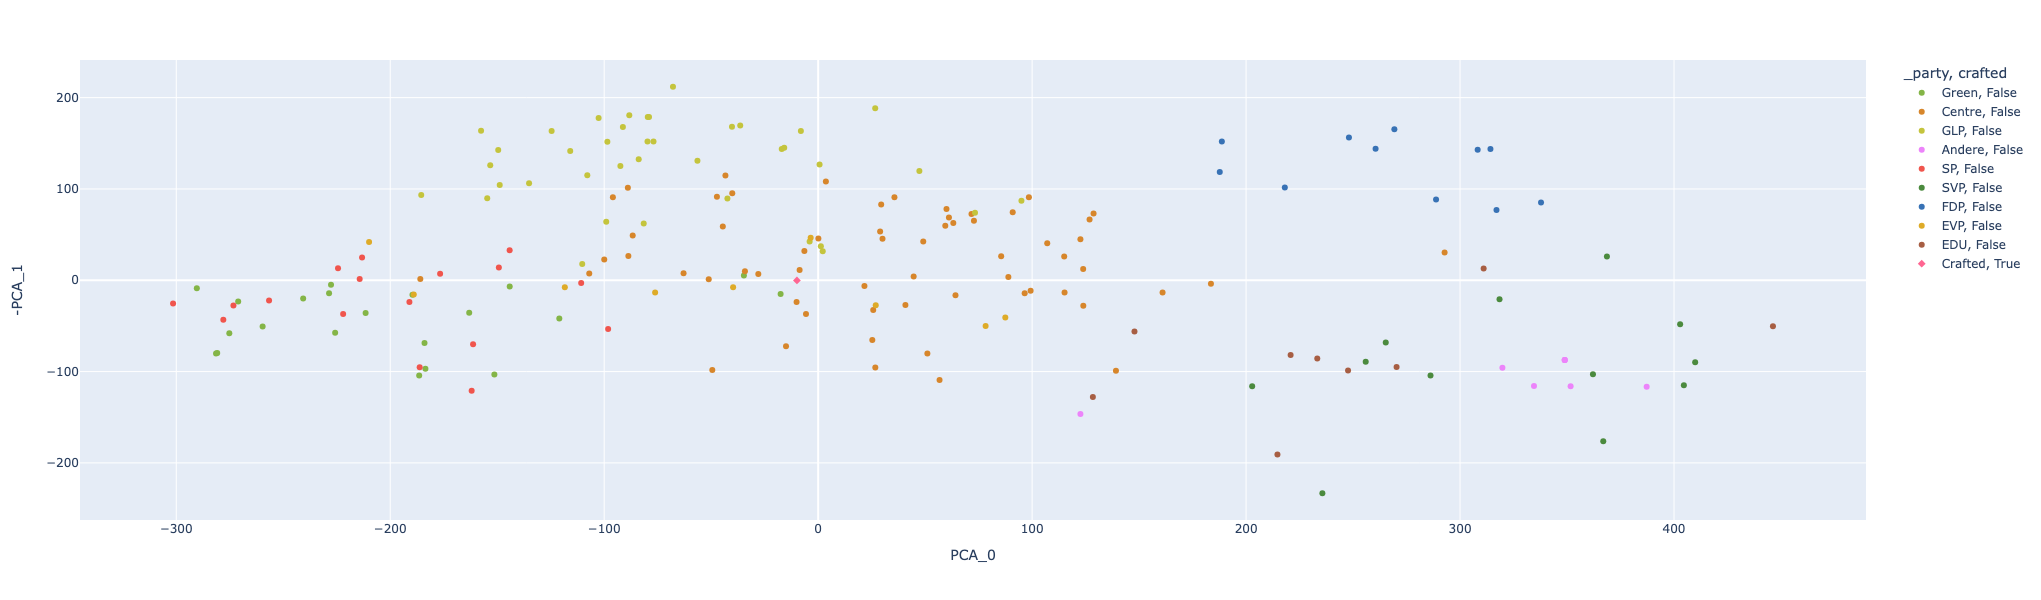

In [61]:
px.scatter(df_c.district('TG'), x='PCA_0', y='-PCA_1', color='_party', symbol='crafted', height=600, width=900, color_discrete_map=PARTY2COLOR)

In [25]:
df_crafted_candidates

,Canton,# Extreme,answer_32214,answer_32215,answer_32216,answer_32217,answer_32218,answer_32219,answer_32220,answer_32221,answer_32222,answer_32223,answer_32224,answer_32225,answer_32226,answer_32227,answer_32228,answer_32229,answer_32230,answer_32231,answer_32232,answer_32233,answer_32234,answer_32235,answer_32236,answer_32237,answer_32238,answer_32239,answer_32240,answer_32241,answer_32242,answer_32243,answer_32244,answer_32245,answer_32246,answer_32247,answer_32248,answer_32249,answer_32250,answer_32251,answer_32252,answer_32253,answer_32254,answer_32255,answer_32256,answer_32257,answer_32258,answer_32259,answer_32260,answer_32261,answer_32262,answer_32263,answer_32264,answer_32265,answer_32266,answer_32267,answer_32268,answer_32269,answer_32270,answer_32271,answer_32272,answer_32273,answer_32274,answer_32275,answer_32276,answer_32277,answer_32278,answer_32279,answer_32280,answer_32281,answer_32282,answer_32283,answer_32284,answer_32285,answer_32286,answer_32287,answer_32288,PCA_0,-PCA_0,PCA_1,-PCA_1,CA_0,-CA_0,CA_1,-CA_1
0,TI,0,25.0,75.0,75.0,25.0,75.0,75.0,75.0,75.0,25.0,25.0,75.0,75.0,25.0,75.0,25.0,25.0,25.0,75.0,75.0,75.0,25.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,25.0,75.0,25.0,75.0,75.0,75.0,25.0,75.0,75.0,25.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,25.0,25.0,75.0,25.0,25.0,25.0,75.0,25.0,75.0,25.0,75.0,25.0,25.0,50.0,50.0,67.0,50.0,67.0,33.0,83.0,75.0,75.0,50.0,75.0,50.0,50.0,50.0,75.0,-47.923211,47.923211,49.565648,-49.565648,-0.082388,0.082388,0.134503,-0.134503
1,LU,1,25.0,75.0,75.0,25.0,75.0,75.0,25.0,75.0,25.0,25.0,75.0,25.0,75.0,75.0,25.0,75.0,25.0,75.0,75.0,75.0,25.0,100.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,25.0,75.0,75.0,75.0,25.0,75.0,25.0,75.0,75.0,25.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,25.0,25.0,25.0,25.0,75.0,75.0,75.0,25.0,75.0,75.0,75.0,25.0,25.0,67.0,50.0,67.0,33.0,67.0,33.0,83.0,50.0,75.0,50.0,75.0,25.0,50.0,50.0,50.0,-35.958600,35.958600,-10.593220,10.593220,-0.054982,0.054982,0.010432,-0.010432
2,GE,1,25.0,75.0,75.0,25.0,75.0,75.0,75.0,75.0,25.0,25.0,75.0,75.0,25.0,75.0,25.0,75.0,25.0,75.0,75.0,75.0,25.0,75.0,75.0,75.0,25.0,75.0,75.0,75.0,25.0,25.0,75.0,25.0,75.0,25.0,75.0,25.0,75.0,75.0,25.0,75.0,75.0,75.0,75.0,100.0,75.0,75.0,75.0,75.0,25.0,75.0,25.0,25.0,25.0,75.0,25.0,75.0,25.0,75.0,25.0,25.0,50.0,33.0,67.0,33.0,67.0,33.0,83.0,75.0,75.0,75.0,75.0,25.0,50.0,25.0,75.0,-61.389340,61.389340,62.147831,-62.147831,-0.108577,0.108577,0.160975,-0.160975
3,TG,0,25.0,75.0,75.0,25.0,75.0,75.0,25.0,75.0,25.0,25.0,75.0,25.0,25.0,75.0,25.0,75.0,25.0,75.0,75.0,75.0,25.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,25.0,75.0,75.0,25.0,75.0,75.0,25.0,75.0,75.0,25.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,25.0,25.0,25.0,75.0,75.0,75.0,25.0,75.0,75.0,75.0,25.0,25.0,67.0,50.0,67.0,33.0,67.0,50.0,67.0,50.0,75.0,50.0,75.0,25.0,75.0,50.0,50.0,-9.924167,9.924167,0.227530,-0.227530,0.000534,-0.000534,0.028435,-0.028435
4,ZH,2,25.0,75.0,75.0,25.0,75.0,75.0,25.0,75.0,25.0,25.0,75.0,75.0,25.0,75.0,25.0,75.0,25.0,75.0,75.0,75.0,25.0,100.0,25.0,100.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,25.0,75.0,25.0,75.0,25.0,75.0,75.0,25.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,25.0,25.0,25.0,25.0,75.0,75.0,75.0,25.0,75.0,75.0,75.0,25.0,25.0,50.0,50.0,67.0,17.0,67.0,33.0,83.0,75.0,75.0,50.0,75.0,25.0,50.0,25.0,50.0,-66.536317,66.536317,-16.232591,16.232591,-0.128540,0.128540,0.012783,-0.012783
5,FR,1,25.0,75.0,75.0,25.0,75.0,75.0,25.0,75.0,25.0,25.0,75.0,75.0,25.0,75.0,25.0,75.0,25.0,75.0,75.0,75.0,25.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,25.0,75.0,75.0,25.0,25.0,75.0,25.0,75.0,75.0,25.0,75.0,75.0,75.0,75.0,100.0,75.0,75.0,75.0,25.0,25.0,75.0,25.0,75.0,25.0,75.0,25.0,75.0,25.0,75.0,25.0,25.0,50.0,50.0,67.0,33.0,67.0,33.0,83.0,75.0,75.0,50.0,75.0,50.0,50.0,25.0,50.0,-43.996355,43.996355,31.434975,-31.434975,-0.071228,0.071228,0.091425,-0.091425
6,AG,0,25.0,75.0,75.0,25.0,75.0,75.0,25.0,75.0,25.0,25.0,75.0,25.0,75.0,75.0,25.0,75.0,25.0,75.0,75.0,75.0,25.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,75.0,25.0,75.0,75.0,25.0,25.0,75.0,25.0

In [6]:
district = 'ZH'
candidate_answer_vector = np.load(f'answer_optimization/answer_optimization_vector_{district}.npy')


In [10]:
(candidate_answer_vector== 100).sum()

2

In [99]:
district = 'JU'

df_v_district = df_voters.district(district)
df_c_district = df_candidates.district(district)

candidate_answer_vector = np.load(f'answer_optimization/answer_optimization_vector_{district}.npy')

df_c_district_crafted_candidate = add_crafted_candidate(df_c_district, candidate_answer_vector)
df_v = add_candidate_voting_recommendations(df_v_district, df_c_district_crafted_candidate)
df_c_district_crafted_candidate = df_c_district_crafted_candidate.add_recommendation_counts(df_v)

df_c_district_crafted_candidate['_n_recommendations_spc_L2_sv'] / df_c_district_crafted_candidate['_n_recommendations_top_L2_sv'].sum()

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/3039 [00:00<?, ?it/s]

0     0.600856
1     0.044093
2     0.053965
3     0.014808
4     0.107272
5     0.017111
6     0.019085
7     0.071734
8     0.038170
9     0.015795
10    0.069760
11    0.075354
12    0.010201
13    0.067785
14    0.041132
15    0.086542
16    0.039816
17    0.014149
18    0.010201
19    0.003949
20    0.071734
21    0.065811
22    0.063508
23    0.081277
24    0.003291
25    0.010859
26    0.031918
27    0.053636
28    0.039158
29    0.003949
30    0.076341
31    0.039816
32    0.020072
33    0.021060
34    0.015795
Name: _n_recommendations_spc_L2_sv, dtype: float64

In [100]:
# verify objective visibility same as add_recommendation_counts visibility

threshold_dists = df_v_district[f'_matchDist_{SEATS_PER_CANTON[district]}_L2_sv'].to_numpy()

voter_answers = df_v_district.a().to_numpy()
voter_weights = df_v_district.w().to_numpy()
crafted_candidate_dists = calculate_distances(voter_answers, candidate_answer_vector.reshape(1, -1), voter_weights)
visibility = (crafted_candidate_dists.ravel() <= threshold_dists).mean()

visibility


0.6008555445870352